# code for 2D trajectory embedding using UMAP

### imports

In [1]:
import numpy as np
import hypertools as hyp
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import math
import os
import pickle
from numpy import ma
import pycircstat
from statsmodels.stats.multitest import multipletests as mt

cmap = plt.cm.Spectral
%matplotlib inline

### set some paths

In [2]:
norm_term = 1000
ep_model_dir = '../../data/models/episodes/t100_w50/'
ep_traj_dir = os.path.join(ep_model_dir, 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 'events')
ep_emb_dir = os.path.join(ep_model_dir, 'embeddings', 'k:'+str(norm_term))
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:'+str(norm_term))
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings', 'k:'+str(norm_term))
pickle_dir = '../../data/pickles/'

### load some data

In [3]:
# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir):
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}
        
# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)

In [ ]:
for rectype in embeddings_dict.keys():
    no_rec_mask = np.all(np.equal(avg_participant_events[rectype], 0), axis=1)
    avg_participant_events[rectype] = avg_participant_events[rectype][~no_rec_mask]

## define some functions & classes

In [4]:
class Point:
    def __init__(self, coord=None):
        self.coord = np.array(coord)

In [5]:
class LineSegment:  
    def __init__(self, p1=None, p2=None):
        if isinstance(p1, Point):
            self.p1 = p1
        else:
            self.p1 = Point(p1)
            
        if isinstance(p2, Point):
            self.p2 = p2
        else:
            self.p2 = Point(p2)
        
    def intersect(self, z):
        if isinstance(z, Circle):
            return _seg_intersect_circle(self, z)
        elif isinstance(x, Rectangle):
            return _seg_intersect_rect(self, z)
        
    def norm(self):
        diff = self.p2.coord-self.p1.coord
        return diff/np.linalg.norm(diff)
    
    def get_p1(self):
        return self.p1.coord
    
    def get_p2(self):
        return self.p2.coord
    
    def get_vec(self):
        return self.p2.coord-self.p1.coord
        
    def angle(self, ref=None):
        if ref==None:
            p1 = np.zeros_like(self.get_p1())
            p2 = np.zeros_like(self.get_p1())
            p2[0] = 1
            ref = LineSegment(p1, p2)
        v0 = ref.get_vec()
        v1 = self.get_vec()
        return np.arccos(v0.dot(v1)/(np.linalg.norm(v0)*np.linalg.norm(v1)))

In [6]:
class Circle:
    def __init__(self, center=None, r=None):
        self.center = np.array(center)
        self.r = r 
    
    def get_center(self):
        return self.center
    
    def get_radius(self):
        return self.r

In [7]:
class Rectangle:
    def __init__(self, x=None, y=None, w=None):
        self.c0 = x-w
        self.c1 = y-w
        self.c2 = x+w
        self.c3 = y+w

In [8]:
def _seg_intersect_circle(ls, circ):
     
    Q = circ.get_center()
    r = circ.get_radius()
    P1 = ls.get_p1()
    V = ls.get_p2() - P1
    
    a = V.dot(V)
    b = 2 * V.dot(P1 - Q)
    c = P1.dot(P1) + Q.dot(Q) - 2 * P1.dot(Q) - r**2
    
    disc = b**2 - 4 * a * c
    if disc < 0:
        return False
    
    sqrt_disc = math.sqrt(disc)
    t1 = (-b + sqrt_disc) / (2 * a)
    t2 = (-b - sqrt_disc) / (2 * a)
    if not (0 <= t1 <= 1 or 0 <= t2 <= 1):
        return False
    
    return True

In [9]:
def _seg_intersect_rect(ls, r):
    
    # find min/max X for the segment
    minX = min(ls.p1.x, ls.p2.x)
    maxX = max(ls.p1.x, ls.p2.x)
    
    # find the intersection of the segment's and rectangle's x-projections
    if maxX > r.c2:
        maxX = r.c2
    if minX < r.c0:
        minX = r.c0
    
    if minX > maxX:
        return False
    
    minY = ls.p1.y
    maxY = ls.p2.y
    
    dx = ls.p2.x - ls.p1.x
    
    if abs(dx) > .0000001:
        a = (ls.p2.y - ls.p1.y) / dx
        b = ls.p1.y - a * ls.p1.x
        minY = a * minX + b
        maxY = a * maxX + b
        
    if minY > maxY:
        tmp = maxY
        maxY = minY
        minY = tmp
        
    # find the intersection of the segment's and rectangle's y-projections
    if maxY > r.c3:
        maxY = r.c3
    if minY < r.c1:
        minY = r.c1
        
    # if Y-projections do not intersect return false
    if minY > maxY:
        return False
    else:
        return True

In [10]:
def add_arrows(axes, x, y, **kwargs):

    # spacing of arrows
    aspace = .05 # good value for scale of 1
    aspace *= scale

    # r is the distance spanned between pairs of points
    r = [0]
    for i in range(1,len(x)):
        dx = x[i]-x[i-1]
        dy = y[i]-y[i-1]
        r.append(np.sqrt(dx*dx+dy*dy))
    r = np.array(r)

    # rtot is a cumulative sum of r, it's used to save time
    rtot = []
    for i in range(len(r)):
        rtot.append(r[0:i].sum())
    rtot.append(r.sum())

    arrowData = [] # will hold tuples of x,y,theta for each arrow
    arrowPos = 0 # current point on walk along data
    rcount = 1 
    while arrowPos < r.sum():
        x1,x2 = x[rcount-1],x[rcount]
        y1,y2 = y[rcount-1],y[rcount]
        da = arrowPos-rtot[rcount] 
        theta = np.arctan2((x2-x1),(y2-y1))
        ax = np.sin(theta)*da+x1
        ay = np.cos(theta)*da+y1
        arrowData.append((ax,ay,theta))
        arrowPos+=aspace
        while arrowPos > rtot[rcount+1]: 
            rcount+=1
            if arrowPos > rtot[-1]:
                break

    # could be done in above block if you want
    for ax,ay,theta in arrowData:
        # use aspace as a guide for size and length of things
        # scaling factors were chosen by experimenting a bit
        axes.arrow(ax,ay,
                   np.sin(theta)*aspace/10,np.cos(theta)*aspace/10, 
                   head_width=aspace/3, **kwargs)

In [11]:
def compute_coord(xi, yi, w, seglist, kind='rectangle'):
    
    if kind=='rectangle':
        z = Rectangle(x=xi, y=yi, w=w)
    elif kind=='circle':
        z = Circle(center=[xi,yi], r=w)
        
    segs = list(filter(lambda s: s.intersect(z), seglist))
    
    if len(segs)>1:
        u, v  = np.array([seg.norm() for seg in segs]).mean(0)
        rads = np.array([seg.angle() for seg in segs])
        p, z = pycircstat.tests.rayleigh(rads)
    else:
        u = 0
        v = 0
        p = 1
    c = len(segs)
    return u, v, p, c

## create 2D embeddings

In [105]:
alg = 'UMAP'
seed = 15

embeddings_dict = {'atlep1' : None, 'atlep2' : None, 'arrdev' : None, 'delayed': None, 'prediction' : None}
for rectype in embeddings_dict.keys():
    print('reducing ' + rectype)
    
    # set correct episode model for participant audio type
    if rectype == 'delayed' or rectype == 'prediction':
        ep_events = episode_events['atlep1']
        ep_traj = episode_trajectories['atlep1']
    else:
        ep_events = episode_events[rectype]
        ep_traj = episode_trajectories[rectype]
        
    np.random.seed(seed)
    
    
    embeddings = hyp.reduce([evs for (turkid, evs) in participant_events[rectype]] + [ep_events] 
                            + [avg_participant_events[rectype]], reduce=alg, ndims=2)
    
    indv_events = [(turkid, emb) for (turkid, _), emb in zip(participant_events[rectype], embeddings[:-2])]
    
    embeddings_dict[rectype] = {'episode_events' : embeddings[-2], 'avg_participant_events' : embeddings[-1], 
                                'participants_events' : indv_events}

#     embeddings = hyp.reduce([evs for (turkid, evs) in participant_events[rectype]] + [ep_traj] 
#                             + [avg_participant_trajectories[rectype]]+ [ep_events] 
#                             + [avg_participant_events[rectype]], reduce=alg, ndims=2)
    
#     indv_events = [(turkid, emb) for (turkid, _), emb in zip(participant_events[rectype], embeddings[:-5])]
    
#     embeddings_dict[rectype] = {'episode_trajectory' : embeddings[-4], 'episode_events' : embeddings[-2],
#                                 'avg_participant_trajectory' : embeddings[-3],
#                                'avg_participant_events' : embeddings[-1], 'participants_events' : indv_events}

#     embeddings = hyp.reduce([traj for (turkid, traj) in participant_trajectories[rectype]]
#                             + [evs for (turkid, evs) in participant_events[rectype]] + 
#                             [avg_participant_trajectories[rectype]] + [ep_traj] + [ep_events] + 
#                             [avg_participant_events[rectype]], reduce=alg, ndims=2)
#     indvs = embeddings[:-4]
    
#     indv_traj = [(turkid, emb) for (turkid, _), emb in zip(participant_trajectories[rectype], 
#                                                            indvs[:len(indvs)//2])]
#     indv_events = [(turkid, emb) for (turkid, _), emb in zip(participant_events[rectype], 
#                                                            indvs[len(indvs)//2:])]
    
#     embeddings_dict[rectype] = {'episode_trajectory' : embeddings[-3], 'episode_events' : embeddings[-2], 
#                                 'avg_participant_trajectory' : embeddings[-4],
#                                 'avg_participant_events' : embeddings[-1], 'participants_trajectories' : indv_traj,
#                                'participants_events' : indv_events}


reducing atlep1
reducing atlep2
reducing arrdev
reducing delayed
reducing prediction


## save embeddings

In [106]:
# for rectype, data in embeddings_dict.items():
#     for emb_type, emb in data.items():
#         if emb_type == 'episode_trajectory':
#             np.save(os.path.join(ep_emb_dir,rectype+'-trajectory.npy'), emb)
#         elif emb_type == 'episode_events':
#             np.save(os.path.join(ep_emb_dir,rectype+'-events.npy'), emb)
#         elif emb_type == 'avg_participant_trajectory':
#             np.save(os.path.join(rec_emb_dir,rectype,'avg_participant_trajectory.npy'), emb)
#         elif emb_type == 'avg_participant_events':
#             np.save(os.path.join(rec_emb_dir,rectype,emb_type+'.npy'), emb)
#         else:
#             for turkid, e in emb:
#                 np.save(os.path.join(rec_emb_dir,rectype, turkid+'.npy'), e)

## load in saved embeddings

In [107]:
# embeddings_dict = {'atlep1' : None, 'atlep2' : None, 'arrdev' : None, 'delayed': None, 'prediction' : None}


# for rectype in embeddings_dict.keys():
#     embeddings_dict[rectype] = {'episode_trajectory' : None, 'episode_events' : None, 
#                                 'avg_participant_trajectory' : None, 'avg_participant_events' : None,
#                                 'participant_events' : None}
    
#     embeddings_dict[rectype]['episode_trajectory'] = np.load(os.path.join(ep_emb_dir,rectype+'-trajectory.npy'))
    
#     embeddings_dict[rectype]['episode_events'] = np.load(os.path.join(ep_emb_dir,rectype+'-events.npy'))
    
#     embeddings_dict[rectype]['avg_participant_trajectory'] = np.load(os.path.join(rec_emb_dir,rectype,
#                                                                               'avg_participant_trajectory.npy'))
    
#     embeddings_dict[rectype]['avg_participant_events'] = np.load(os.path.join(rec_emb_dir,rectype,
#                                                                               'avg_participant_events.npy'))
    
#     individuals = []
#     for f_name in [f for f in os.listdir(os.path.join(rec_emb_dir,rectype)) if f.startswith('debug')]:
#         individuals.append((os.path.splitext(f_name)[0], np.load(os.path.join(rec_emb_dir,rectype,f_name))))
#     embeddings_dict[rectype]['participant_events'] = individuals

## filter video events with no successful recalls from average embedded recall events model

In [108]:
for rectype in embeddings_dict.keys():
    no_rec_mask = np.all(np.equal(avg_participant_events[rectype], 0), axis=1)
    embeddings_dict[rectype]['avg_participant_events'] = embeddings_dict[rectype]['avg_participant_events']\
    [~no_rec_mask]

## plot resuls from each

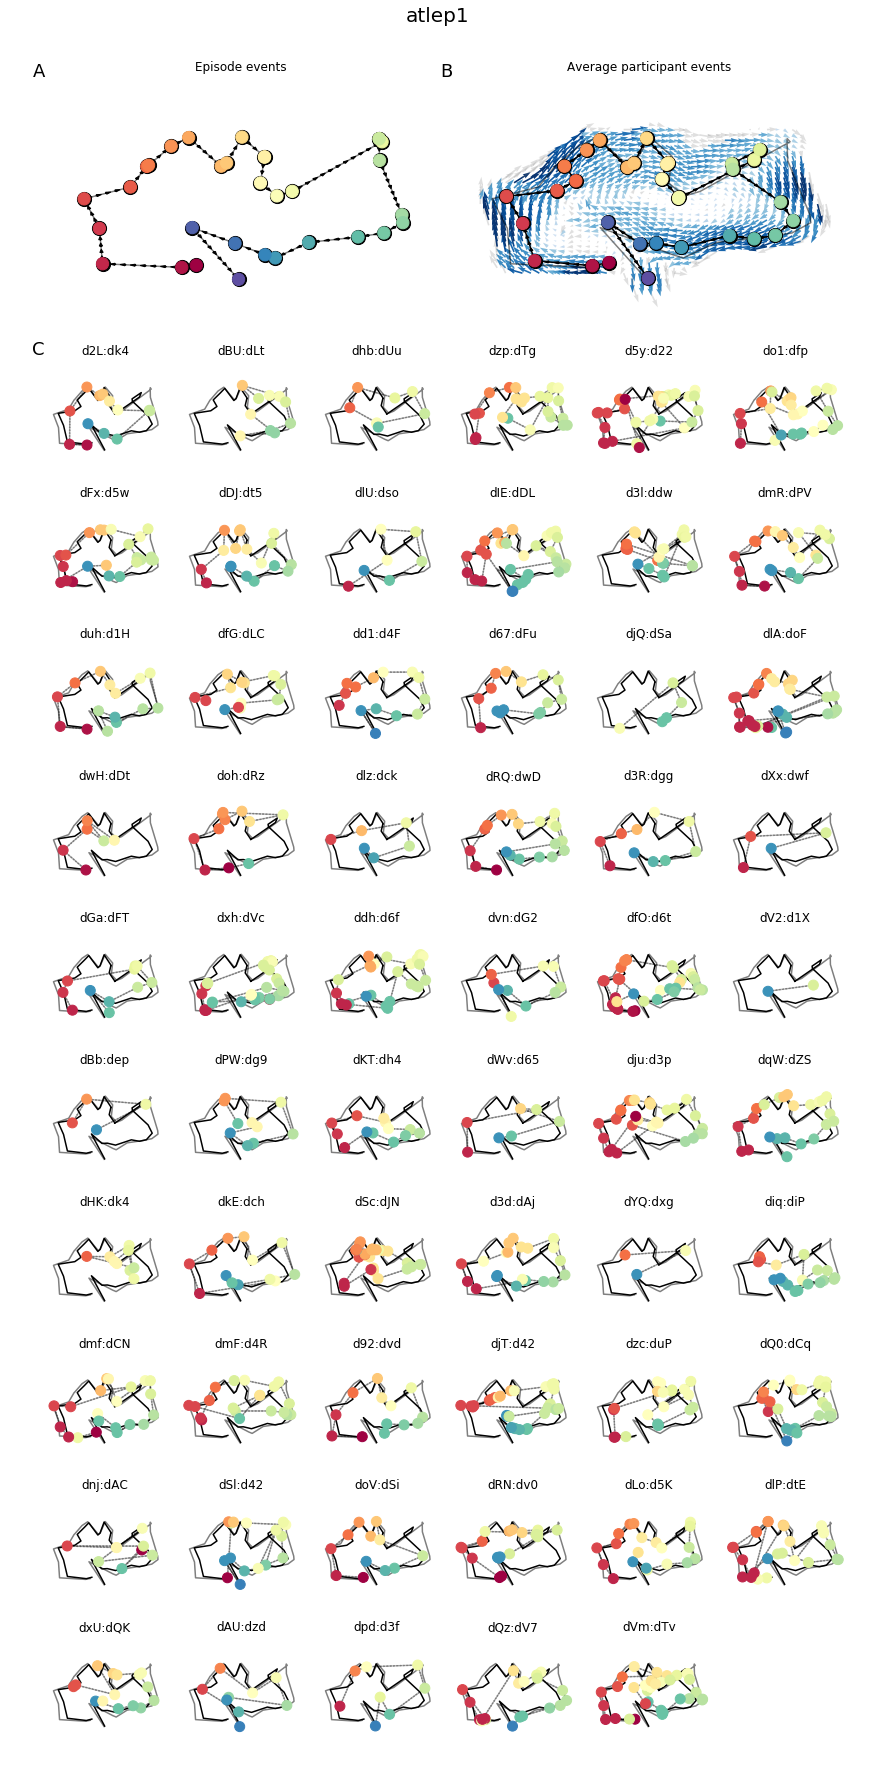

In [109]:
for rectype, data in embeddings_dict.items():
    # set some variables
    episode_es = data['episode_events']
    avg_participant = data['avg_participant_events']
    individuals = data['participants_events']
    mappings = event_mappings[rectype]

    # create a 2D grid
#     scale = int(episode_es.max())+1
#     scale = int(np.concatenate([abs(i[1]) for i in individuals]).max())*1.1
    scale = np.abs(episode_es).max()*1.25
    step = scale / 24
    X, Y = np.meshgrid(np.arange(-scale, scale, step), np.arange(-scale, scale, step))

    # turn embedded recall event model into a list of line segments
    seglist = []
    for i, (turkid, sub_emb) in enumerate(embeddings_dict[rectype]['participants_events']):
        for j in range(sub_emb.shape[0]-1):
            p1 = Point(coord=sub_emb[j, :])
            p2 = Point(coord=sub_emb[j+1, :])
            seg = LineSegment(p1=p1, p2=p2)

            seglist.append(seg)

    # compute the average vector and p-value at each grid point
    U = np.zeros_like(X)
    V = np.zeros_like(X)
    P = np.zeros_like(X)
    Z = np.zeros_like(X)
    C = np.zeros_like(X)
    for i, (x, y) in enumerate(zip(X, Y)):
        for j, (xi, yi) in enumerate(zip(x, y)):
            U[i, j], V[i, j], P[i, j], C[i, j] = compute_coord(xi, yi, step*2, seglist, kind='circle')

    # multiple comparisons correction
    thresh = .001
    Pc = mt(P.ravel(), method='fdr_bh', alpha=.05)[1].reshape(np.shape(X))
    M = np.hypot(U, V)
    M = plt.cm.Blues(M)
    M[Pc>thresh]=[.5, .5, .5, .25]
    M[Pc==1]=[.5, .5, .5, 0]


    # create figure with subplots
    plt.figure(figsize=(12,(len(individuals)//6+3)*2))
    mpl.rcParams['pdf.fonttype'] = 42
    axarr = [0 for i in range(2)]

    axarr[0] = plt.subplot2grid((len(individuals)//6+3, 6), (0, 0), colspan=3, rowspan=2)
    axarr[1] = plt.subplot2grid((len(individuals)//6+3, 6), (0, 3), colspan=3, rowspan=2)

    for i in range(2, (len(individuals)//6+3)):
        for j in range(0, 6):
            ax = plt.subplot2grid((len(individuals)//6+3, 6), (i, j))
            axarr.append(ax)

    # plot episode trajectory and events
    axarr[0].scatter(episode_es[:, 0], episode_es[:, 1], c=range(episode_es.shape[0]), 
                     cmap=cmap, s=150, zorder=3)
    axarr[0].scatter(episode_es[:, 0], episode_es[:, 1], c='k', cmap=cmap, s=200, zorder=2)
    axarr[0].plot(episode_es[:, 0], episode_es[:, 1], zorder=1, c='k', alpha=.5)
    #axarr[0].plot(episode_trajectory[:, 0], episode_trajectory[:, 1], zorder=1, c='k', alpha=.5)
    add_arrows(axarr[0], episode_es[:, 0], episode_es[:, 1], zorder=0, alpha=1, color='k', fill=True)
    axarr[0].set_title('Episode events')
    axarr[0].set_xlim(-scale, scale)
    axarr[0].set_ylim(-scale, scale)
    axarr[0].text(0, 1,'A',
            horizontalalignment='center',
            transform=axarr[0].transAxes,
              fontsize=18)

    # plot average participant events
    axarr[1].quiver(X, Y, U, V, color=M.reshape(M.shape[0]*M.shape[1],4), zorder=1, width=.004)
    axarr[1].plot(avg_participant[:, 0], avg_participant[:, 1], zorder=2, c='k', alpha=1)
    axarr[1].plot(episode_es[:, 0], episode_es[:, 1], zorder=1, c='k', alpha=.5)
    add_arrows(axarr[1], avg_participant[:, 0], avg_participant[:, 1], zorder=3, alpha=1, color='k', fill=True)
    axarr[1].scatter(avg_participant[:, 0], avg_participant[:, 1], c=range(avg_participant.shape[0]), cmap=cmap, 
                     s=150, zorder=4)
    #axarr[1].plot(avg_p_trajectory[:, 0], avg_p_trajectory[:, 1], zorder=1, c='k', alpha=.5)
    axarr[1].scatter(avg_participant[:, 0], avg_participant[:, 1], c='k', cmap=cmap, s=200, zorder=3)
    axarr[1].set_title('Average participant events')
    axarr[1].set_xlim(-scale, scale)
    axarr[1].set_ylim(-scale, scale)
    axarr[1].text(0, 1,'B',
            horizontalalignment='center',
            transform=axarr[1].transAxes,
              fontsize=18)

    # plot individual participants
    axarr[2].text(0, 1.05, 'C', horizontalalignment='center', transform=axarr[2].transAxes, fontsize=18)

    for i, (turkid, e) in enumerate(individuals):
        for tid, m in mappings:
            if turkid == tid:
                axarr[i+2].scatter(e[:,0], e[:,1], c=cmap(m/34), cmap=cmap, s=100, zorder=2)
                axarr[i+2].plot(e[:,0], e[:,1], zorder=1, c='k', alpha=.25)
                axarr[i+2].plot(avg_participant[:, 0], avg_participant[:, 1], zorder=1, c='k', alpha=1)
                axarr[i+2].plot(episode_es[:, 0], episode_es[:, 1], zorder=1, c='k', alpha=.5)
                add_arrows(axarr[i+2], e[:,0], e[:,1], zorder=1, alpha=.25, color='k', fill=True)
                #axarr[i+2].plot(episode_trajectory[:, 0], episode_trajectory[:, 1], c='k', zorder=3)
                #axarr[i+2].plot(episode_es[:, 0], episode_es[:, 1], c='k', zorder=3)
                axarr[i+2].set_xlim(-scale, scale)
                axarr[i+2].set_ylim(-scale, scale)
                axarr[i+2].set_title(':'.join([i.replace('debug','d')[:3] for i in turkid.split(':')]))

    for a in axarr:
        a.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=.025, hspace=.25)
    plt.suptitle(rectype, y=1.025, ha='center', fontsize=20)
    plt.savefig('../../figures/embeddings/'+rectype+'-'+alg+'-'+'seed'+str(seed)+'_no_traj_stats.pdf')

# embed immediate and delayed recall together

In [18]:
embeddings = hyp.reduce([evs for (turkid, evs) in participant_events['atlep1']] 
                        + [evs for (turkid, evs) in participant_events['delayed']] + [episode_events['atlep1']]
                        + [avg_participant_events['atlep1']] + [avg_participant_events['delayed']], 
                        reduce=alg, ndims=2)

indvs = embeddings[:-4]

indv_imm = [(turkid, emb) for (turkid, _), emb in zip(participant_events[rectype], indvs[:len(indvs)//2])]
indv_del = [(turkid, emb) for (turkid, _), emb in zip(participant_events[rectype], indvs[len(indvs)//2:])]
    
imm_del_embs = {'episode_events' : embeddings[-3], 'avg_participant_immediate' : embeddings[-2],
                'avg_participant_delayed' : embeddings[-1], 'participants_immediate' : indv_imm, 
               'participants_delayed' : indv_del}

## filter episode events with no recalls from average participant embedding

In [19]:
no_irec_mask = np.all(np.equal(avg_participant_events['atlep1'], 0), axis=1)
imm_del_embs['avg_participant_immediate'] = imm_del_embs['avg_participant_immediate'][~no_irec_mask]
no_drec_mask = np.all(np.equal(avg_participant_events['delayed'], 0), axis=1)
imm_del_embs['avg_participant_delayed'] = imm_del_embs['avg_participant_delayed'][~no_drec_mask]

## plot the comparison

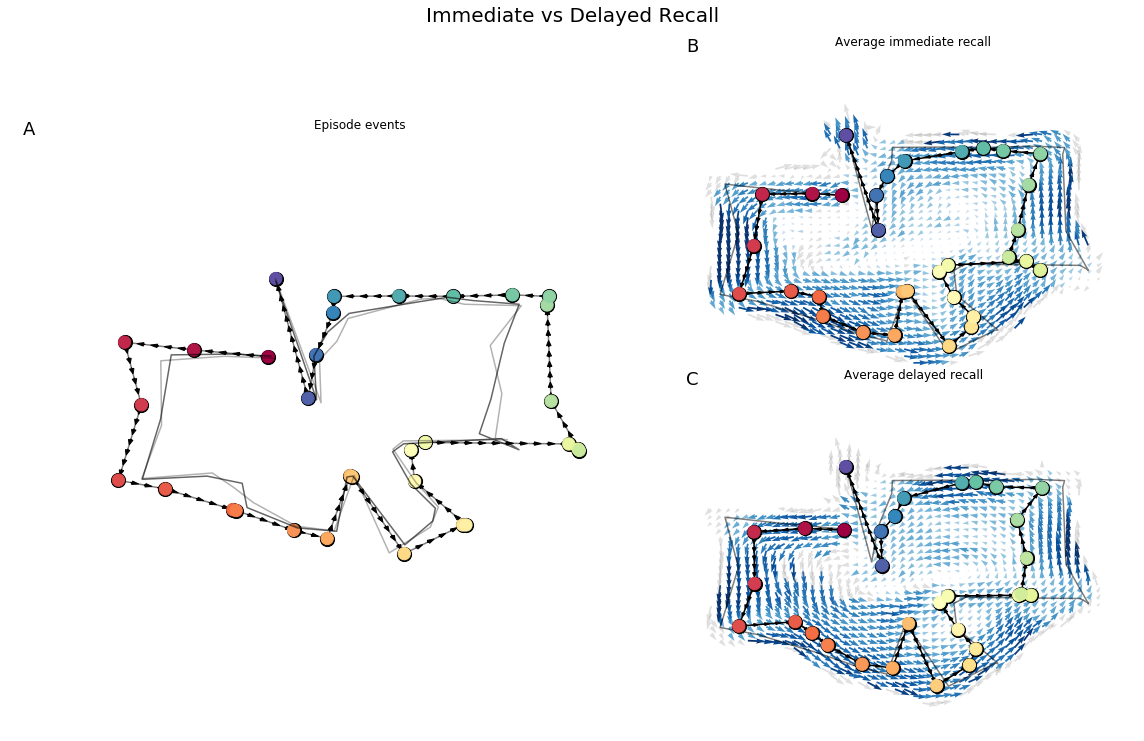

In [27]:
# shorten some variable names
episode_es = imm_del_embs['episode_events']
avg_p_imm = imm_del_embs['avg_participant_immediate']
avg_p_del = imm_del_embs['avg_participant_delayed']
ps_imm = imm_del_embs['participants_immediate']
ps_del = imm_del_embs['participants_delayed']

imm_mappings = event_mappings['atlep1']
del_mappings = event_mappings['delayed']

# create a 2D grid
#     scale = int(np.argmax([abs(i) for i in episode_es]))


scale = int(np.concatenate([abs(i[1]) for i in ps_imm]+[abs(i[1]) for i in ps_del]).max())+1
step = scale / 24

X, Y = np.meshgrid(np.arange(-scale, scale, step), np.arange(-scale, scale, step))

# turn embedded recall event model into a list of line segments
imm_seglist = []
for i, (turkid, sub_emb) in enumerate(ps_imm):
    for j in range(sub_emb.shape[0]-1):
        p1 = Point(coord=sub_emb[j, :])
        p2 = Point(coord=sub_emb[j+1, :])
        seg = LineSegment(p1=p1, p2=p2)

        imm_seglist.append(seg)
        
del_seglist = []
for i, (turkid, sub_emb) in enumerate(ps_del):
    for j in range(sub_emb.shape[0]-1):
        p1 = Point(coord=sub_emb[j, :])
        p2 = Point(coord=sub_emb[j+1, :])
        seg = LineSegment(p1=p1, p2=p2)

        del_seglist.append(seg)

# compute the average vector and p-value at each grid point
iU = np.zeros_like(X)
iV = np.zeros_like(X)
iP = np.zeros_like(X)
iZ = np.zeros_like(X)
iC = np.zeros_like(X)
for i, (x, y) in enumerate(zip(X, Y)):
    for j, (xi, yi) in enumerate(zip(x, y)):
        iU[i, j], iV[i, j], iP[i, j], iC[i, j] = compute_coord(xi, yi, step*2, imm_seglist, kind='circle')

dU = np.zeros_like(X)
dV = np.zeros_like(X)
dP = np.zeros_like(X)
dZ = np.zeros_like(X)
dC = np.zeros_like(X)
for i, (x, y) in enumerate(zip(X, Y)):
    for j, (xi, yi) in enumerate(zip(x, y)):
        dU[i, j], dV[i, j], dP[i, j], dC[i, j] = compute_coord(xi, yi, step*2, del_seglist, kind='circle')

# multiple comparisons correction
thresh = .001
iPc = mt(iP.ravel(), method='fdr_bh', alpha=.05)[1].reshape(48,48)
iM = np.hypot(iU, iV)
iM = plt.cm.Blues(iM)
iM[iPc>thresh]=[.5, .5, .5, .25]
iM[iPc==1]=[.5, .5, .5, 0]

thresh = .001
dPc = mt(dP.ravel(), method='fdr_bh', alpha=.05)[1].reshape(48,48)
dM = np.hypot(dU, dV)
dM = plt.cm.Blues(dM)
dM[dPc>thresh]=[.5, .5, .5, .25]
dM[dPc==1]=[.5, .5, .5, 0]


# create figure with subplots
plt.figure(figsize=(16,10))
mpl.rcParams['pdf.fonttype'] = 42
axarr = [0 for i in range(3)]

# axarr[0] = plt.subplot2grid((8, 6), (0, 0), colspan=6, rowspan=4)
# axarr[1] = plt.subplot2grid((8, 6), (4, 0), colspan=3, rowspan=2)
# axarr[2] = plt.subplot2grid((8, 6), (4, 3), colspan=3, rowspan=2)

axarr[0] = plt.subplot2grid((8, 10), (1, 0), rowspan=6, colspan=6)
axarr[1] = plt.subplot2grid((8, 10), (0, 6), rowspan=4, colspan=4)
axarr[2] = plt.subplot2grid((8, 10), (4, 6), rowspan=4, colspan=4)




# plot episode trajectory and events
axarr[0].scatter(episode_es[:, 0], episode_es[:, 1], c=range(episode_es.shape[0]), 
                 cmap=cmap, s=150, zorder=3)
axarr[0].scatter(episode_es[:, 0], episode_es[:, 1], c='k', cmap=cmap, s=200, zorder=2)
axarr[0].plot(episode_es[:, 0], episode_es[:, 1], zorder=1, c='k', alpha=.5)
#axarr[0].plot(episode_trajectory[:, 0], episode_trajectory[:, 1], zorder=1, c='k', alpha=.5)
add_arrows(axarr[0], episode_es[:, 0], episode_es[:, 1], zorder=0, alpha=1, color='k', fill=True)
axarr[0].plot(avg_p_imm[:, 0], avg_p_imm[:, 1], zorder=3, c='k', alpha=0.6)
axarr[0].plot(avg_p_del[:, 0], avg_p_del[:, 1], zorder=3, c='k', alpha=0.3)
axarr[0].set_title('Episode events')
axarr[0].set_xlim(-scale*1.2, scale*1.2)
axarr[0].set_ylim(-scale*1.2, scale*1.2)
axarr[0].text(0, 1,'A',
        horizontalalignment='center',
        transform=axarr[0].transAxes,
          fontsize=18)

# plot average immediate recall events
axarr[1].quiver(X, Y, iU, iV, color=iM.reshape(iM.shape[0]*iM.shape[1],4), zorder=1, width=.004)
axarr[1].plot(avg_p_imm[:, 0], avg_p_imm[:, 1], zorder=2, c='k', alpha=1)
axarr[1].plot(episode_es[:, 0], episode_es[:, 1], zorder=1, c='k', alpha=.5)
add_arrows(axarr[1], avg_p_imm[:, 0], avg_p_imm[:, 1], zorder=3, alpha=1, color='k', fill=True)
axarr[1].scatter(avg_p_imm[:, 0], avg_p_imm[:, 1], c=range(avg_p_imm.shape[0]), cmap=cmap, 
                 s=150, zorder=4)
#axarr[1].plot(avg_p_trajectory[:, 0], avg_p_trajectory[:, 1], zorder=1, c='k', alpha=.5)
axarr[1].scatter(avg_p_imm[:, 0], avg_p_imm[:, 1], c='k', cmap=cmap, s=200, zorder=3)
axarr[1].set_title('Average immediate recall')
axarr[1].set_xlim(-scale, scale)
axarr[1].set_ylim(-scale, scale)
axarr[1].text(0, 1,'B',
        horizontalalignment='center',
        transform=axarr[1].transAxes,
          fontsize=18)

# plot average delayed recall events
axarr[2].quiver(X, Y, dU, dV, color=dM.reshape(dM.shape[0]*dM.shape[1],4), zorder=1, width=.004)
axarr[2].plot(avg_p_del[:, 0], avg_p_del[:, 1], zorder=2, c='k', alpha=1)
axarr[2].plot(episode_es[:, 0], episode_es[:, 1], zorder=1, c='k', alpha=.5)
add_arrows(axarr[2], avg_p_del[:, 0], avg_p_del[:, 1], zorder=3, alpha=1, color='k', fill=True)
axarr[2].scatter(avg_p_del[:, 0], avg_p_del[:, 1], c=range(avg_p_del.shape[0]), cmap=cmap, 
                 s=150, zorder=4)
#axarr[1].plot(avg_p_trajectory[:, 0], avg_p_trajectory[:, 1], zorder=1, c='k', alpha=.5)
axarr[2].scatter(avg_p_del[:, 0], avg_p_del[:, 1], c='k', cmap=cmap, s=200, zorder=3)
axarr[2].set_title('Average delayed recall')
axarr[2].set_xlim(-scale, scale)
axarr[2].set_ylim(-scale, scale)
axarr[2].text(0, 1,'C',
        horizontalalignment='center',
        transform=axarr[2].transAxes,
          fontsize=18)

# # plot individual participants
# axarr[2].text(0, 1.05, 'C', horizontalalignment='center', transform=axarr[2].transAxes, fontsize=18)

# for i, (turkid, e) in enumerate(individuals):
#     for tid, m in mappings:
#         if turkid == tid:
#             axarr[i+2].scatter(e[:,0], e[:,1], c=cmap(m/34), cmap=cmap, s=100, zorder=2)
#             axarr[i+2].plot(e[:,0], e[:,1], zorder=1, c='k', alpha=.25)
#             axarr[i+2].plot(avg_participant[:, 0], avg_participant[:, 1], zorder=1, c='k', alpha=1)
#             axarr[i+2].plot(episode_es[:, 0], episode_es[:, 1], zorder=1, c='k', alpha=.5)
#             add_arrows(axarr[i+2], e[:,0], e[:,1], zorder=1, alpha=.25, color='k', fill=True)
#             #axarr[i+2].plot(episode_trajectory[:, 0], episode_trajectory[:, 1], c='k', zorder=3)
#             #axarr[i+2].plot(episode_es[:, 0], episode_es[:, 1], c='k', zorder=3)
#             axarr[i+2].set_xlim(-scale, scale)
#             axarr[i+2].set_ylim(-scale, scale)
#             axarr[i+2].set_title(':'.join([i.replace('debug','d')[:3] for i in turkid.split(':')]))

for a in axarr:
    a.axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=.01, hspace=.01)
plt.suptitle('Immediate vs Delayed Recall', y=1.025, ha='center', fontsize=20)
plt.savefig('../../figures/embeddings/'+'imm-del'+'-'+alg+'-'+'seed'+str(seed)+'_no_traj_stats.pdf')


In [51]:
int(np.concatenate([abs(i[1]) for i in individuals]).max())*1.1

13.200000000000001

In [56]:
np.abs(episode_es).max()

4.1498513064264735